# Corpus Charcot vs. Autres

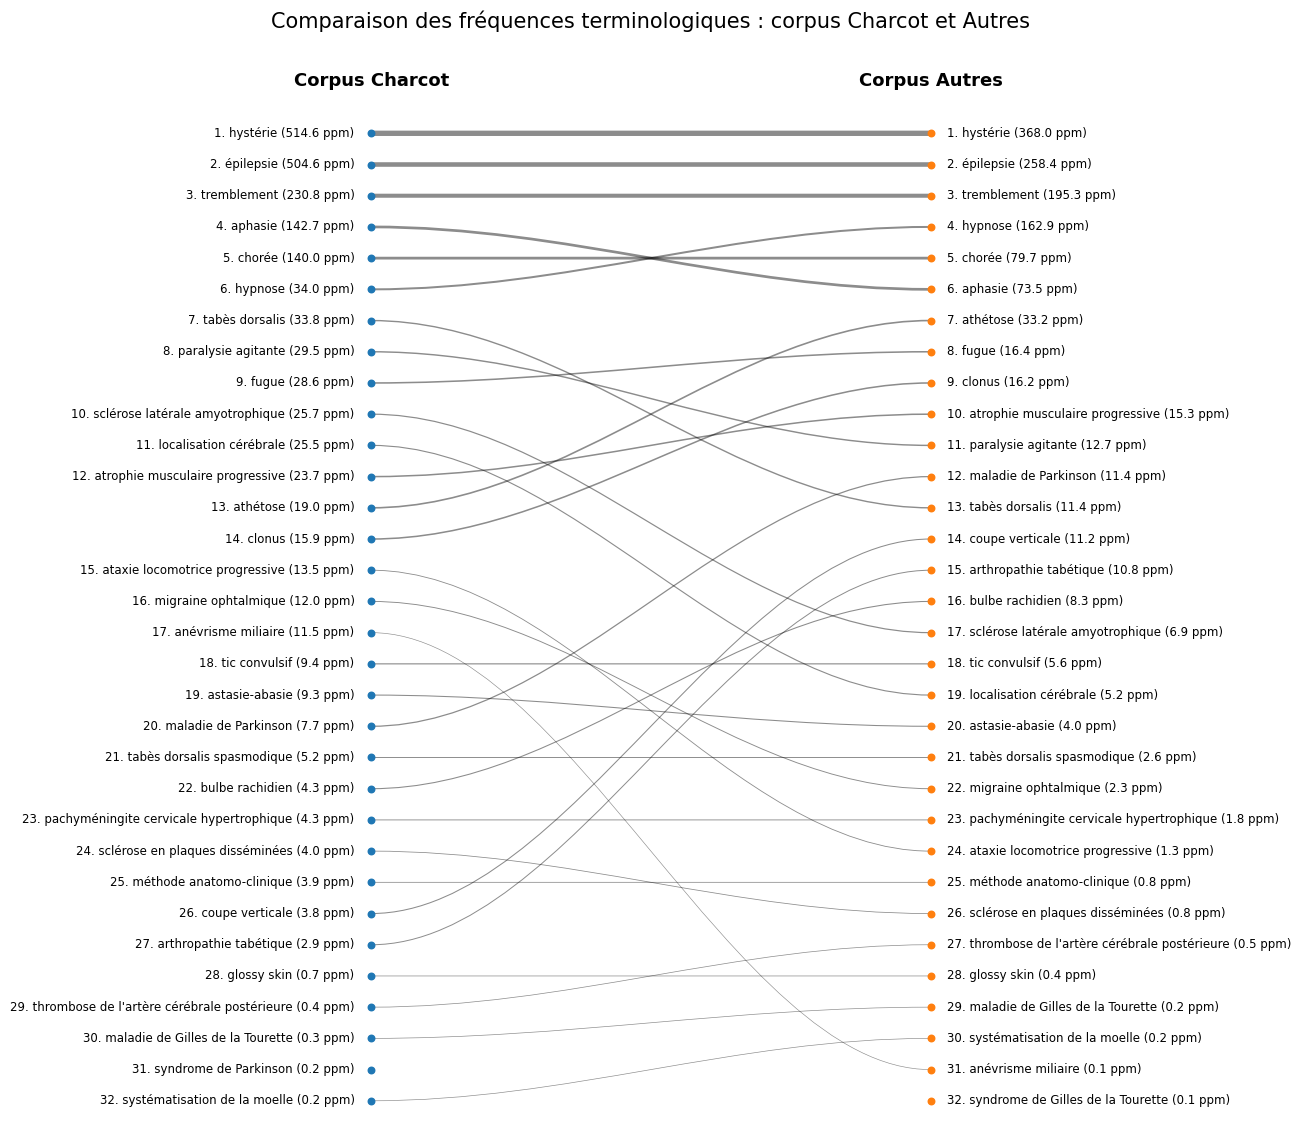

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from pathlib import Path as FilePath


# =========================
# Fichiers d'entrée / sortie
# =========================

# Fichiers contenant les fréquences annuelles des expressions
# pour chacun des deux corpus.
CHARCOT_CSV = FilePath("frequences_detaillees_charcot.csv")
AUTRES_CSV = FilePath("frequences_detaillees_autres.csv")

# Fichiers produits par le script.
OUTPUT_PNG = FilePath("comparaison_gambette_charcot_autres.png")
OUTPUT_PDF = FilePath("comparaison_gambette_charcot_autres.pdf")
OUTPUT_CSV = FilePath("comparaison_frequences_charcot_autres.csv")


# =========================
# Préparation des données
# =========================

def inferer_type_terme(expression):
    """
    Classe automatiquement les expressions en deux catégories :
    - terme simple : pas d'espace, par exemple "hystérie" ;
    - terme composé : au moins un espace, par exemple "sclérose latérale amyotrophique".

    Cette distinction sert surtout si l'on veut ensuite filtrer ou colorer les termes.
    """
    expression = str(expression).strip()
    return "composé" if " " in expression else "simple"


def charger_et_agreger(path, nom_corpus):
    """
    Charge un fichier CSV de fréquences annuelles et calcule une fréquence globale
    pour chaque expression dans l'ensemble du corpus.

    Attention :
    le fichier d'origine contient une ligne par expression et par année.
    Les valeurs de freq_ppm sont donc des fréquences annuelles.

    Pour comparer les deux corpus globalement, on ne doit pas additionner les freq_ppm.
    On doit :
    1. additionner les occurrences de chaque expression ;
    2. additionner les tokens du corpus ;
    3. recalculer une fréquence globale en ppm.
    """

    df = pd.read_csv(path)

    # On vérifie que le fichier contient bien les colonnes nécessaires.
    colonnes_attendues = {"date", "total_tokens", "expression", "occurrences"}
    colonnes_manquantes = colonnes_attendues - set(df.columns)

    if colonnes_manquantes:
        raise ValueError(
            f"Colonnes manquantes dans {path.name} : {colonnes_manquantes}"
        )

    # total_tokens est répété pour chaque expression d'une même année.
    # Il faut donc garder une seule ligne par année avant de sommer les tokens.
    total_tokens_corpus = (
        df[["date", "total_tokens"]]
        .drop_duplicates()
        ["total_tokens"]
        .sum()
    )

    # On additionne les occurrences de chaque expression sur toutes les années.
    agg = (
        df.groupby("expression", as_index=False)
        .agg(occurrences=("occurrences", "sum"))
    )

    # On renomme les colonnes pour garder la trace du corpus :
    # occurrences_charcot, ppm_charcot, occurrences_autres, ppm_autres.
    agg[f"occurrences_{nom_corpus}"] = agg["occurrences"]

    # Fréquence globale normalisée en occurrences par million de tokens.
    agg[f"ppm_{nom_corpus}"] = (
        agg["occurrences"] / total_tokens_corpus * 1_000_000
    )

    # La colonne temporaire "occurrences" n'est plus nécessaire,
    # puisqu'elle a été renommée avec le nom du corpus.
    agg = agg.drop(columns=["occurrences"])

    return agg, total_tokens_corpus


def attribuer_rang_stable(df, colonne_ppm, colonne_rang):
    """
    Attribue un rang stable à partir d'une colonne de fréquence en ppm.

    Pourquoi ne pas utiliser seulement rank(method="first") ?
    Parce que method="first" dépend de l'ordre initial des lignes dans le DataFrame.
    Or, pour l'affichage final, les termes sont retriés par fréquence.
    Avec des fréquences très proches ou identiques après arrondi, cela peut créer
    une incohérence entre le rang affiché et la position visuelle du terme.

    Ici, on impose donc un ordre stable :
    1. fréquence en ppm décroissante ;
    2. expression alphabétique en cas d'égalité ou de valeurs très proches.
    """

    ordre = (
        df.sort_values(
            by=[colonne_ppm, "expression"],
            ascending=[False, True]
        )
        .index
    )

    df[colonne_rang] = 0
    df.loc[ordre, colonne_rang] = np.arange(1, len(df) + 1)

    return df


def preparer_comparaison(charcot_csv, autres_csv):
    """
    Construit un tableau comparatif contenant, pour chaque expression :
    - ses occurrences dans Charcot ;
    - sa fréquence globale en ppm dans Charcot ;
    - ses occurrences dans Autres ;
    - sa fréquence globale en ppm dans Autres ;
    - son rang dans chaque corpus ;
    - son changement de rang ;
    - son ratio Charcot / Autres.
    """

    charcot, tokens_charcot = charger_et_agreger(charcot_csv, "charcot")
    autres, tokens_autres = charger_et_agreger(autres_csv, "autres")

    # Fusion des deux tableaux sur la colonne "expression".
    # how="outer" permet de garder aussi les expressions présentes dans un seul corpus.
    df = pd.merge(charcot, autres, on="expression", how="outer")

    # Les valeurs manquantes correspondent aux expressions absentes d'un corpus.
    # On les remplace donc par 0.
    df["occurrences_charcot"] = df["occurrences_charcot"].fillna(0).astype(int)
    df["occurrences_autres"] = df["occurrences_autres"].fillna(0).astype(int)

    df["ppm_charcot"] = df["ppm_charcot"].fillna(0)
    df["ppm_autres"] = df["ppm_autres"].fillna(0)

    # Catégorisation simple / composé.
    df["type_terme"] = df["expression"].apply(inferer_type_terme)

    # Rang dans chaque corpus :
    # rang 1 = expression la plus fréquente.
    #
    # On utilise une fonction de rang stable pour éviter les incohérences
    # entre le rang affiché et la position visuelle dans le graphique.
    # En cas de fréquences identiques ou très proches, les expressions sont
    # départagées alphabétiquement.
    df = attribuer_rang_stable(df, "ppm_charcot", "rang_charcot")
    df = attribuer_rang_stable(df, "ppm_autres", "rang_autres")

    # Changement de rang entre les deux corpus.
    # Une valeur positive signifie que le terme est moins bien classé dans Autres que dans Charcot.
    # Une valeur négative signifie qu'il est mieux classé dans Autres.
    df["delta_rang"] = df["rang_autres"] - df["rang_charcot"]

    # Fréquence commune utilisée pour l'épaisseur du lien.
    # On prend le minimum des deux fréquences afin de ne pas représenter un faux "flux"
    # de Charcot vers Autres.
    df["ppm_commun"] = df[["ppm_charcot", "ppm_autres"]].min(axis=1)

    # Différence directe de fréquence normalisée.
    # Valeur positive : terme plus fréquent dans Charcot.
    # Valeur négative : terme plus fréquent dans Autres.
    df["diff_ppm_charcot_moins_autres"] = df["ppm_charcot"] - df["ppm_autres"]

    # Ratio de fréquence Charcot / Autres.
    # On ajoute une petite constante epsilon pour éviter les divisions par zéro
    # lorsque le terme est absent d'un des deux corpus.
    epsilon = 0.5

    df["ratio_charcot_autres"] = (
        (df["occurrences_charcot"] + epsilon) / tokens_charcot
    ) / (
        (df["occurrences_autres"] + epsilon) / tokens_autres
    )

    # On garde les tailles des corpus dans le tableau final,
    # ce qui permet de vérifier les calculs plus tard.
    df["tokens_charcot"] = tokens_charcot
    df["tokens_autres"] = tokens_autres

    # Tri par fréquence décroissante dans le corpus Charcot.
    # Le tri secondaire alphabétique garde une cohérence avec les rangs stables.
    df = df.sort_values(
        by=["ppm_charcot", "expression"],
        ascending=[False, True]
    )

    return df


# =========================
# Dessin des liens
# =========================

def courbe_bezier(ax, x0, y0, x1, y1, linewidth=1.0, alpha=0.45):
    """
    Dessine une courbe de Bézier entre deux points.

    Ce type de courbe permet d'obtenir des liens courbes,
    visuellement proches des diagrammes inspirés de Sankey ou de Gambette.
    """

    # Points de contrôle de la courbe.
    # Le premier et le dernier point sont les extrémités.
    # Les deux points intermédiaires contrôlent la courbure.
    verts = [
        (x0, y0),
        (x0 + 0.35, y0),
        (x1 - 0.35, y1),
        (x1, y1),
    ]

    # Code indiquant à Matplotlib comment interpréter les points.
    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
    ]

    path = MplPath(verts, codes)

    patch = PathPatch(
        path,
        facecolor="none",
        linewidth=linewidth,
        alpha=alpha,
        zorder=1,
    )

    ax.add_patch(patch)


# =========================
# Graphique final
# =========================

def graphique_gambette_like(
    df,
    top_n=None,
    titre="Comparaison des fréquences terminologiques : corpus Charcot et Autres",
    sortie_png=OUTPUT_PNG,
    sortie_pdf=OUTPUT_PDF,
):
    """
    Produit un graphique inspiré des chaînes de formes partagées.

    À gauche :
    les expressions classées par fréquence globale en ppm dans le corpus Charcot.

    À droite :
    les expressions classées par fréquence globale en ppm dans le corpus Autres.

    Les courbes relient les mêmes expressions dans les deux listes.
    L'épaisseur de la courbe dépend de la fréquence commune.
    """

    # Si top_n est défini, on garde l'union des top_n termes
    # les plus fréquents dans Charcot et des top_n termes les plus fréquents dans Autres.
    # Exemple : top_n=20 donne une figure plus lisible qu'une figure avec tous les termes.
    if top_n is not None:
        top_charcot = (
            df.sort_values(
                by=["ppm_charcot", "expression"],
                ascending=[False, True]
            )
            .head(top_n)["expression"]
        )

        top_autres = (
            df.sort_values(
                by=["ppm_autres", "expression"],
                ascending=[False, True]
            )
            .head(top_n)["expression"]
        )

        termes_a_garder = set(top_charcot).union(set(top_autres))
        df_plot = df[df["expression"].isin(termes_a_garder)].copy()

    else:
        df_plot = df.copy()

    # Liste de gauche : termes présents dans Charcot, classés par ppm décroissant.
    # Le tri secondaire alphabétique permet de garder le même ordre que celui
    # utilisé pour calculer les rangs.
    gauche = (
        df_plot[df_plot["ppm_charcot"] > 0]
        .sort_values(
            by=["ppm_charcot", "expression"],
            ascending=[False, True]
        )
        .copy()
    )

    # Liste de droite : termes présents dans Autres, classés par ppm décroissant.
    # Le tri secondaire alphabétique permet d'éviter les inversions visuelles
    # lorsque deux valeurs sont très proches ou identiques après arrondi.
    droite = (
        df_plot[df_plot["ppm_autres"] > 0]
        .sort_values(
            by=["ppm_autres", "expression"],
            ascending=[False, True]
        )
        .copy()
    )

    # Positions verticales des termes.
    # Le terme le plus fréquent est placé en haut.
    gauche["y_charcot"] = np.arange(len(gauche), 0, -1)
    droite["y_autres"] = np.arange(len(droite), 0, -1)

    # Dictionnaires permettant de retrouver rapidement la position verticale
    # d'une expression dans chaque corpus.
    pos_gauche = dict(zip(gauche["expression"], gauche["y_charcot"]))
    pos_droite = dict(zip(droite["expression"], droite["y_autres"]))

    max_y = max(len(gauche), len(droite))

    # Hauteur de la figure ajustée au nombre de termes affichés.
    fig_height = max(8, max_y * 0.36)
    fig, ax = plt.subplots(figsize=(14, fig_height))

    # Positions horizontales des deux colonnes.
    x_left = 0
    x_right = 1

    # Dessin des liens entre les termes présents dans les deux corpus.
    for _, row in df_plot.iterrows():
        terme = row["expression"]

        # On trace un lien seulement si le terme est présent des deux côtés.
        if terme in pos_gauche and terme in pos_droite:
            y0 = pos_gauche[terme]
            y1 = pos_droite[terme]

            # Épaisseur du lien :
            # plus la fréquence commune est élevée, plus le lien est épais.
            valeur_lien = row["ppm_commun"]
            linewidth = 0.4 + np.sqrt(valeur_lien) * 0.18

            courbe_bezier(
                ax,
                x_left,
                y0,
                x_right,
                y1,
                linewidth=linewidth,
                alpha=0.45,
            )

    # Étiquettes du corpus Charcot.
    for _, row in gauche.iterrows():
        y = row["y_charcot"]

        label = (
            f"{int(row['rang_charcot'])}. "
            f"{row['expression']} "
            f"({row['ppm_charcot']:.1f} ppm)"
        )

        ax.text(
            x_left - 0.03,
            y,
            label,
            ha="right",
            va="center",
            fontsize=8.5,
        )

    # Étiquettes du corpus Autres.
    for _, row in droite.iterrows():
        y = row["y_autres"]

        label = (
            f"{int(row['rang_autres'])}. "
            f"{row['expression']} "
            f"({row['ppm_autres']:.1f} ppm)"
        )

        ax.text(
            x_right + 0.03,
            y,
            label,
            ha="left",
            va="center",
            fontsize=8.5,
        )

    # Points marquant les positions des termes dans chaque liste.
    ax.scatter(
        [x_left] * len(gauche),
        gauche["y_charcot"],
        s=22,
        zorder=3,
    )

    ax.scatter(
        [x_right] * len(droite),
        droite["y_autres"],
        s=22,
        zorder=3,
    )

    # Titres des deux colonnes.
    ax.text(
        x_left,
        max_y + 1.5,
        "Corpus Charcot",
        ha="center",
        fontsize=13,
        fontweight="bold",
    )

    ax.text(
        x_right,
        max_y + 1.5,
        "Corpus Autres",
        ha="center",
        fontsize=13,
        fontweight="bold",
    )

    # Suppression des axes : ici, le graphique fonctionne comme une comparaison de listes,
    # pas comme un graphique cartésien classique.
    ax.set_xlim(-0.62, 1.62)
    ax.set_ylim(0, max_y + 2.5)
    ax.axis("off")

    ax.set_title(titre, fontsize=15, pad=20)

    plt.tight_layout()

    # Sauvegarde dans deux formats :
    # PNG pour l'affichage rapide, PDF pour une meilleure qualité dans un document.
    plt.savefig(sortie_png, dpi=300, bbox_inches="tight")
    plt.savefig(sortie_pdf, bbox_inches="tight")

    plt.show()


# =========================
# Exécution du script
# =========================

# Construction du tableau comparatif.
comparaison = preparer_comparaison(CHARCOT_CSV, AUTRES_CSV)

# Sauvegarde du tableau comparatif pour pouvoir vérifier ou réutiliser les valeurs.
comparaison.to_csv(OUTPUT_CSV, index=False)

# Génération du graphique.
# top_n=None : affiche tous les termes.
# top_n=20 ou top_n=25 : affiche une version plus lisible pour une publication.
graphique_gambette_like(
    comparaison,
    top_n=None,
)

# données jouet

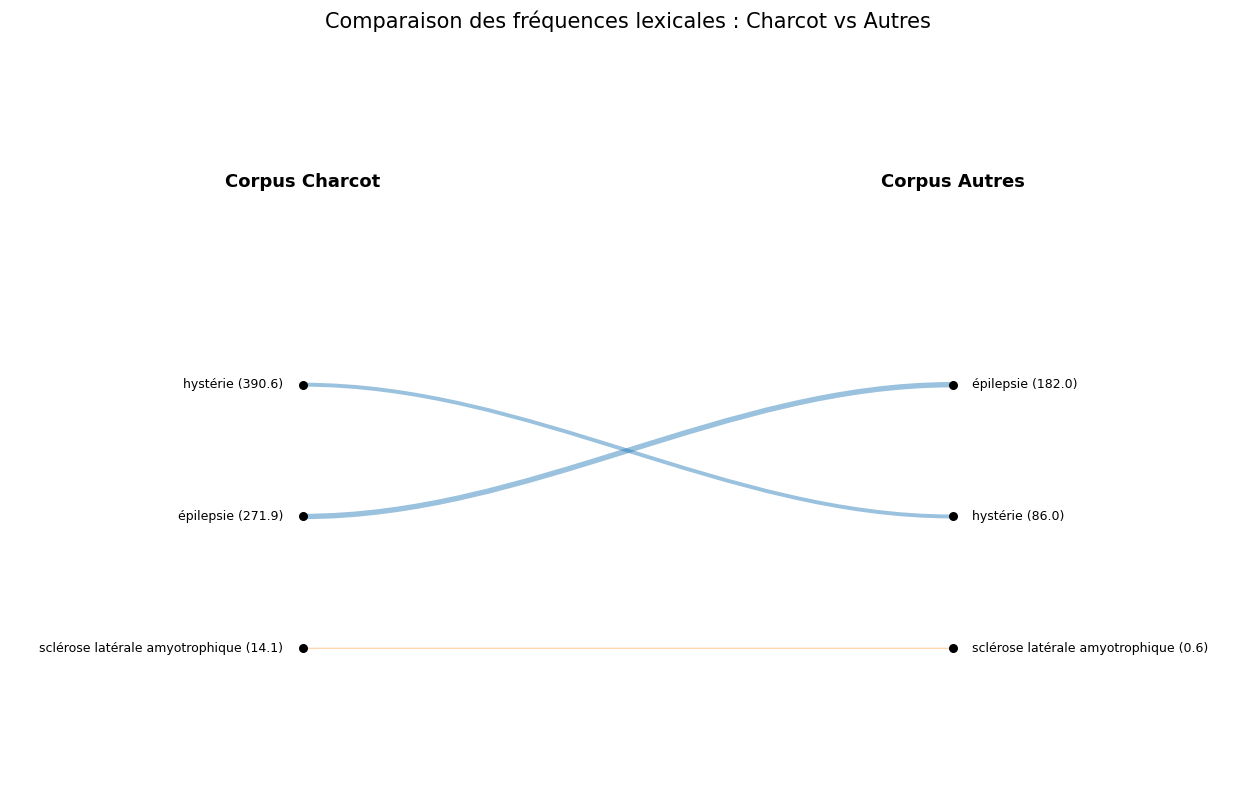

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch


def courbe_bezier(ax, x0, y0, x1, y1, linewidth=1.5, alpha=0.6, color="gray"):
    """
    Dessine une courbe de Bézier entre deux points.
    """
    verts = [
        (x0, y0),
        (x0 + 0.35, y0),
        (x1 - 0.35, y1),
        (x1, y1),
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
    ]

    path = Path(verts, codes)
    patch = PathPatch(
        path,
        facecolor="none",
        edgecolor=color,
        linewidth=linewidth,
        alpha=alpha,
        zorder=1,
    )
    ax.add_patch(patch)


def preparer_donnees(charcot_csv, autres_csv, top_n=40):
    """
    Prépare les données pour comparer les termes des deux corpus.
    Les fichiers doivent contenir au moins :
    terme, type_terme, freq, tokens
    """

    charcot = pd.read_csv(charcot_csv)
    autres = pd.read_csv(autres_csv)

    charcot["ppm_charcot"] = charcot["freq"] / charcot["tokens"] * 1_000_000
    autres["ppm_autres"] = autres["freq"] / autres["tokens"] * 1_000_000

    charcot = charcot.rename(columns={
        "freq": "freq_charcot",
        "type_terme": "type_terme_charcot"
    })

    autres = autres.rename(columns={
        "freq": "freq_autres",
        "type_terme": "type_terme_autres"
    })

    charcot = charcot[["terme", "type_terme_charcot", "freq_charcot", "ppm_charcot"]]
    autres = autres[["terme", "type_terme_autres", "freq_autres", "ppm_autres"]]

    df = pd.merge(charcot, autres, on="terme", how="outer")

    df["type_terme"] = df["type_terme_charcot"].combine_first(df["type_terme_autres"])

    df["freq_charcot"] = df["freq_charcot"].fillna(0)
    df["freq_autres"] = df["freq_autres"].fillna(0)
    df["ppm_charcot"] = df["ppm_charcot"].fillna(0)
    df["ppm_autres"] = df["ppm_autres"].fillna(0)

    df["rank_charcot"] = df["ppm_charcot"].rank(
        method="first",
        ascending=False
    )

    df["rank_autres"] = df["ppm_autres"].rank(
        method="first",
        ascending=False
    )

    top_charcot = df.sort_values("ppm_charcot", ascending=False).head(top_n)["terme"]
    top_autres = df.sort_values("ppm_autres", ascending=False).head(top_n)["terme"]

    termes_a_afficher = set(top_charcot).union(set(top_autres))

    df_plot = df[df["terme"].isin(termes_a_afficher)].copy()

    df_plot = df_plot.sort_values(
        ["ppm_charcot", "ppm_autres"],
        ascending=False
    )

    return df_plot


def graphique_gambette_like(
    df,
    titre="Comparaison des fréquences lexicales : Charcot vs Autres",
    fichier_sortie="comparaison_charcot_autres.png"
):
    """
    Produit un graphique inspiré des chaînes de formes partagées.
    """

    gauche = df[df["ppm_charcot"] > 0].sort_values("ppm_charcot", ascending=False).copy()
    droite = df[df["ppm_autres"] > 0].sort_values("ppm_autres", ascending=False).copy()

    gauche["y_charcot"] = np.arange(len(gauche), 0, -1)
    droite["y_autres"] = np.arange(len(droite), 0, -1)

    pos_gauche = dict(zip(gauche["terme"], gauche["y_charcot"]))
    pos_droite = dict(zip(droite["terme"], droite["y_autres"]))

    max_y = max(len(gauche), len(droite))

    fig, ax = plt.subplots(figsize=(13, max(8, max_y * 0.35)))

    x_left = 0
    x_right = 1

    couleurs = {
        "simple": "tab:blue",
        "composé": "tab:orange"
    }

    for _, row in df.iterrows():
        terme = row["terme"]
        type_terme = row["type_terme"]

        color = couleurs.get(type_terme, "gray")

        present_gauche = terme in pos_gauche
        present_droite = terme in pos_droite

        if present_gauche and present_droite:
            y0 = pos_gauche[terme]
            y1 = pos_droite[terme]

            valeur_lien = min(row["ppm_charcot"], row["ppm_autres"])

            linewidth = 0.5 + np.sqrt(valeur_lien) * 0.25

            courbe_bezier(
                ax,
                x_left,
                y0,
                x_right,
                y1,
                linewidth=linewidth,
                alpha=0.45,
                color=color
            )

    for _, row in gauche.iterrows():
        terme = row["terme"]
        y = row["y_charcot"]
        ppm = row["ppm_charcot"]

        ax.text(
            x_left - 0.03,
            y,
            f"{terme} ({ppm:.1f})",
            ha="right",
            va="center",
            fontsize=9
        )

    for _, row in droite.iterrows():
        terme = row["terme"]
        y = row["y_autres"]
        ppm = row["ppm_autres"]

        ax.text(
            x_right + 0.03,
            y,
            f"{terme} ({ppm:.1f})",
            ha="left",
            va="center",
            fontsize=9
        )

    ax.text(x_left, max_y + 1.5, "Corpus Charcot", ha="center", fontsize=13, fontweight="bold")
    ax.text(x_right, max_y + 1.5, "Corpus Autres", ha="center", fontsize=13, fontweight="bold")

    ax.scatter([x_left] * len(gauche), gauche["y_charcot"], s=30, color="black", zorder=3)
    ax.scatter([x_right] * len(droite), droite["y_autres"], s=30, color="black", zorder=3)

    ax.set_xlim(-0.45, 1.45)
    ax.set_ylim(0, max_y + 2.5)
    ax.axis("off")

    ax.set_title(titre, fontsize=15, pad=20)

    plt.tight_layout()
    plt.savefig(fichier_sortie, dpi=300, bbox_inches="tight")
    plt.show()


# Exemple d'utilisation
df_plot = preparer_donnees(
    "frequences_charcot.csv",
    "frequences_autres.csv",
    top_n=40
)

graphique_gambette_like(
    df_plot,
    fichier_sortie="comparaison_charcot_autres.png"
)